In [ ]:
# Bibliotecas para manipulação e acesso aos dados
import pandas as pd
import duckdb
import numpy as np

# Biblioteca para visualização
import matplotlib.pyplot as plt

# Bibliotecas para modelagem
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Bibliotecas para avaliação do modelo
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve

# Biblioteca para análise de multicolinearidade
from statsmodels.stats.outliers_influence import variance_inflation_factor


(1,)

### Dados

A base utilizada neste projeto é fictícia e foi construída e consultada por meio do SQL durante o desenvolvimento da análise.

A base de dados não está disponível neste repositório.

In [3]:
df.shape 

(1000, 9)

In [4]:
df.columns

Index(['Idade', 'Sexo', 'Escolaridade', 'Tipo_Moradia', 'Saldo_Investimento',
       'Saldo_Conta_Corrente', 'Valor_Emprestimo', 'Duracao_Emprestimo',
       'Inadimplencia'],
      dtype='str')

In [5]:
df.head()

,Idade,Sexo,Escolaridade,Tipo_Moradia,Saldo_Investimento,Saldo_Conta_Corrente,Valor_Emprestimo,Duracao_Emprestimo,Inadimplencia
0,67,M,Graduacao,Propria,Sem investimento,Pouco,1169,6,0
1,22,H,Graduacao,Propria,Pouco,Moderado,5951,48,1
2,49,M,Pos Graduacao,Propria,Pouco,Sem conta,2096,12,0
3,45,M,Graduacao,De favor,Pouco,Pouco,7882,42,0
4,53,M,Graduacao,De favor,Pouco,Pouco,4870,24,1


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   Idade                 1000 non-null   int64
 1   Sexo                  1000 non-null   str  
 2   Escolaridade          1000 non-null   str  
 3   Tipo_Moradia          1000 non-null   str  
 4   Saldo_Investimento    1000 non-null   str  
 5   Saldo_Conta_Corrente  1000 non-null   str  
 6   Valor_Emprestimo      1000 non-null   int64
 7   Duracao_Emprestimo    1000 non-null   int64
 8   Inadimplencia         1000 non-null   int64
dtypes: int64(4), str(5)
memory usage: 70.4 KB


In [9]:
df_modelo = df[
    [
        "Idade",
        "Tipo_Moradia",
        "Saldo_Investimento",
        "Saldo_Conta_Corrente",
        "Valor_Emprestimo",
        "Duracao_Emprestimo",
        "Inadimplencia"
    ]
]

In [10]:
df_modelo.shape

(1000, 7)

In [11]:
for coluna in ["Saldo_Conta_Corrente", "Saldo_Investimento", "Tipo_Moradia"]:
    print(f"\n{coluna}:")
    print(df_modelo[coluna].unique())


Saldo_Conta_Corrente:
<StringArray>
['Pouco', 'Moderado', 'Sem conta', 'Alto']
Length: 4, dtype: str

Saldo_Investimento:
<StringArray>
['Sem investimento', 'Pouco', 'Alto', 'Moderado']
Length: 4, dtype: str

Tipo_Moradia:
<StringArray>
['Propria', 'De favor', 'Alugada']
Length: 3, dtype: str


In [12]:
df_modelo = pd.get_dummies(
    df_modelo,
    columns=[
        "Saldo_Conta_Corrente",
        "Saldo_Investimento",
        "Tipo_Moradia"
    ],
    dtype=int
)

In [13]:
df_modelo.columns

Index(['Idade', 'Valor_Emprestimo', 'Duracao_Emprestimo', 'Inadimplencia',
       'Saldo_Conta_Corrente_Alto', 'Saldo_Conta_Corrente_Moderado',
       'Saldo_Conta_Corrente_Pouco', 'Saldo_Conta_Corrente_Sem conta',
       'Saldo_Investimento_Alto', 'Saldo_Investimento_Moderado',
       'Saldo_Investimento_Pouco', 'Saldo_Investimento_Sem investimento',
       'Tipo_Moradia_Alugada', 'Tipo_Moradia_De favor',
       'Tipo_Moradia_Propria'],
      dtype='str')

In [14]:
df_modelo.shape

(1000, 15)

In [15]:
df_modelo = df_modelo.drop(
    columns=[
        "Saldo_Conta_Corrente_Sem conta",
        "Saldo_Investimento_Pouco",
        "Tipo_Moradia_Propria"
    ]
)

In [16]:
df_modelo.columns

Index(['Idade', 'Valor_Emprestimo', 'Duracao_Emprestimo', 'Inadimplencia',
       'Saldo_Conta_Corrente_Alto', 'Saldo_Conta_Corrente_Moderado',
       'Saldo_Conta_Corrente_Pouco', 'Saldo_Investimento_Alto',
       'Saldo_Investimento_Moderado', 'Saldo_Investimento_Sem investimento',
       'Tipo_Moradia_Alugada', 'Tipo_Moradia_De favor'],
      dtype='str')

In [17]:
df_modelo.shape

(1000, 12)

In [18]:
df_modelo = df_modelo.rename(
    columns={
        "Saldo_Investimento_Sem investimento": 
        "Saldo_Investimento_Sem"
    }
)

In [19]:
df_modelo.columns

Index(['Idade', 'Valor_Emprestimo', 'Duracao_Emprestimo', 'Inadimplencia',
       'Saldo_Conta_Corrente_Alto', 'Saldo_Conta_Corrente_Moderado',
       'Saldo_Conta_Corrente_Pouco', 'Saldo_Investimento_Alto',
       'Saldo_Investimento_Moderado', 'Saldo_Investimento_Sem',
       'Tipo_Moradia_Alugada', 'Tipo_Moradia_De favor'],
      dtype='str')

In [21]:
X = df_modelo.drop(columns=["Inadimplencia"])
y = df_modelo["Inadimplencia"]

In [22]:
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,  # fixa a aleatoriedade para reproduzir a mesma divisão
    stratify=y  # a proporção de inadimplentes e não inadimplentes será preservada nos dois conjuntos.
)

In [23]:
X_treino.shape, X_teste.shape, y_treino.shape, y_teste.shape

((700, 11), (300, 11), (700,), (300,))

In [24]:
modelo = LogisticRegression(max_iter=1000)

modelo.fit(X_treino, y_treino)

c:\Users\cisia\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [26]:
modelo.n_iter_

array([1000], dtype=int32)

In [27]:
scaler = StandardScaler()

In [28]:
scaler.fit(X_treino[[
    "Idade",
    "Valor_Emprestimo",
    "Duracao_Emprestimo"
]])

StandardScaler()

In [ ]:
X_treino[["Idade", "Valor_Emprestimo", "Duracao_Emprestimo"]] = scaler.transform(
    X_treino[["Idade", "Valor_Emprestimo", "Duracao_Emprestimo"]]
)

X_teste[["Idade", "Valor_Emprestimo", "Duracao_Emprestimo"]] = scaler.transform(
    X_teste[["Idade", "Valor_Emprestimo", "Duracao_Emprestimo"]]
)

In [30]:
print("Médias:")
print(X_treino[[
    "Idade",
    "Valor_Emprestimo",
    "Duracao_Emprestimo"
]].mean())

print("\nDesvios-padrão:")
print(X_treino[[
    "Idade",
    "Valor_Emprestimo",
    "Duracao_Emprestimo"
]].std())

Médias:
Idade                -9.389315e-17
Valor_Emprestimo     -8.628019e-17
Duracao_Emprestimo    1.370332e-16
dtype: float64

Desvios-padrão:
Idade                 1.000715
Valor_Emprestimo      1.000715
Duracao_Emprestimo    1.000715
dtype: float64


In [31]:
vif = pd.DataFrame()

vif["Variável"] = X_treino.columns

vif["VIF"] = [
    variance_inflation_factor(X_treino.values, i)
    for i in range(X_treino.shape[1])
]

vif.sort_values("VIF", ascending=False)

,Variável,VIF
1,Valor_Emprestimo,1.819096
2,Duracao_Emprestimo,1.777574
10,Tipo_Moradia_De favor,1.269062
9,Tipo_Moradia_Alugada,1.263741
4,Saldo_Conta_Corrente_Moderado,1.248402
8,Saldo_Investimento_Sem,1.225021
3,Saldo_Conta_Corrente_Alto,1.192742
5,Saldo_Conta_Corrente_Pouco,1.176195
7,Saldo_Investimento_Moderado,1.162289
0,Idade,1.123586


In [32]:
modelo = LogisticRegression(max_iter=1000)

modelo.fit(X_treino, y_treino)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [34]:
y_pred = modelo.predict(X_teste)

y_prob = modelo.predict_proba(X_teste)[:, 1]

In [35]:
matriz = confusion_matrix(y_teste, y_pred)

matriz

array([[188,  22],
       [ 56,  34]])

In [36]:
acuracia = accuracy_score(y_teste, y_pred)
precisao = precision_score(y_teste, y_pred)
recall = recall_score(y_teste, y_pred)
f1 = f1_score(y_teste, y_pred)

acuracia, precisao, recall, f1

(0.74, 0.6071428571428571, 0.37777777777777777, 0.4657534246575342)

In [37]:
auc = roc_auc_score(y_teste, y_prob)

auc

0.7658730158730159

In [38]:
fpr, tpr, thresholds = roc_curve(y_teste, y_prob)

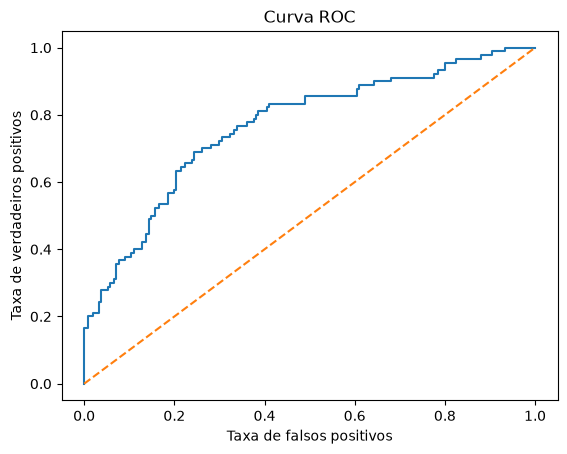

In [39]:
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("Taxa de falsos positivos")
plt.ylabel("Taxa de verdadeiros positivos")
plt.title("Curva ROC")
plt.show()

In [40]:
#Identificação do ponto da curva ROC e do respectivo threshold
indice = np.argmin((fpr - 0.20)**2 + (tpr - 0.65)**2) #pontos com maior TPR (0.65) e menor FPR (0.20)

fpr[indice], tpr[indice], thresholds[indice]

(np.float64(0.21428571428571427),
 np.float64(0.6444444444444445),
 np.float64(0.3832652761017658))

In [41]:
thresholds_avaliados = [0.30, 0.38, 0.40, 0.50, 0.60, 0.70]

for threshold in thresholds_avaliados:
    y_pred_threshold = (y_prob >= threshold).astype(int)
    
    print(
        f"Threshold: {threshold:.2f} | "
        f"Acurácia: {accuracy_score(y_teste, y_pred_threshold):.2f} | "
        f"Precisão: {precision_score(y_teste, y_pred_threshold):.2f} | "
        f"Recall: {recall_score(y_teste, y_pred_threshold):.2f} | "
        f"F1: {f1_score(y_teste, y_pred_threshold):.2f}"
    )

Threshold: 0.30 | Acurácia: 0.69 | Precisão: 0.49 | Recall: 0.77 | F1: 0.59
Threshold: 0.38 | Acurácia: 0.74 | Precisão: 0.56 | Recall: 0.64 | F1: 0.60
Threshold: 0.40 | Acurácia: 0.73 | Precisão: 0.55 | Recall: 0.57 | F1: 0.56
Threshold: 0.50 | Acurácia: 0.74 | Precisão: 0.61 | Recall: 0.38 | F1: 0.47
Threshold: 0.60 | Acurácia: 0.74 | Precisão: 0.76 | Recall: 0.21 | F1: 0.33
Threshold: 0.70 | Acurácia: 0.74 | Precisão: 1.00 | Recall: 0.12 | F1: 0.22


In [42]:
resultados_threshold = []

for threshold in thresholds_avaliados:
    y_pred_threshold = (y_prob >= threshold).astype(int)

    resultados_threshold.append({
        "Threshold": threshold,
        "Acurácia": accuracy_score(y_teste, y_pred_threshold),
        "Precisão": precision_score(y_teste, y_pred_threshold),
        "Recall": recall_score(y_teste, y_pred_threshold),
        "F1-score": f1_score(y_teste, y_pred_threshold)
    })

pd.DataFrame(resultados_threshold)

,Threshold,Acurácia,Precisão,Recall,F1-score
0,0.30,0.686667,0.485915,0.766667,0.594828
1,0.38,0.743333,0.563107,0.644444,0.601036
2,0.40,0.733333,0.554348,0.566667,0.560440
3,0.50,0.740000,0.607143,0.377778,0.465753
4,0.60,0.743333,0.760000,0.211111,0.330435
5,0.70,0.736667,1.000000,0.122222,0.217822


In [43]:
y_pred_30 = (y_prob >= 0.30).astype(int)

matriz_30 = confusion_matrix(y_teste, y_pred_30)

matriz_30

array([[137,  73],
       [ 21,  69]])

In [44]:
y_pred_30 = (y_prob >= 0.30).astype(int)

acuracia_30 = accuracy_score(y_teste, y_pred_30)
precisao_30 = precision_score(y_teste, y_pred_30)
recall_30 = recall_score(y_teste, y_pred_30)
f1_30 = f1_score(y_teste, y_pred_30)

acuracia_30, precisao_30, recall_30, f1_30

(0.6866666666666666,
 0.4859154929577465,
 0.7666666666666667,
 0.5948275862068966)

In [45]:
threshold_final = 0.30

y_pred_final = (y_prob >= threshold_final).astype(int)

In [46]:
matriz_final = confusion_matrix(y_teste, y_pred_final)

matriz_final

array([[137,  73],
       [ 21,  69]])

In [47]:
acuracia_final = accuracy_score(y_teste, y_pred_final)
precisao_final = precision_score(y_teste, y_pred_final)
recall_final = recall_score(y_teste, y_pred_final)
f1_final = f1_score(y_teste, y_pred_final)

acuracia_final, precisao_final, recall_final, f1_final

(0.6866666666666666,
 0.4859154929577465,
 0.7666666666666667,
 0.5948275862068966)

In [48]:
comparacao_matriz = pd.DataFrame(
    {
        "Threshold 0,50": [188, 22, 56, 34],
        "Threshold 0,30": [137, 73, 21, 69]
    },
    index=[
        "Verdadeiros negativos (TN)",
        "Falsos positivos (FP)",
        "Falsos negativos (FN)",
        "Verdadeiros positivos (TP)"
    ]
)

comparacao_matriz

,"Threshold 0,50","Threshold 0,30"
Verdadeiros negativos (TN),188,137
Falsos positivos (FP),22,73
Falsos negativos (FN),56,21
Verdadeiros positivos (TP),34,69


In [49]:
coeficientes = modelo.coef_[0]

coeficientes

array([-0.08173694, -0.0254079 ,  0.44122409,  0.60710085,  1.3907061 ,
        1.57065454, -0.71582582, -0.17216856, -0.72101258,  0.58270369,
        0.36784775])

In [50]:
coeficientes_df = pd.DataFrame({
    "Variavel": X_treino.columns,
    "Coeficiente": coeficientes
})

coeficientes_df

,Variavel,Coeficiente
0,Idade,-0.081737
1,Valor_Emprestimo,-0.025408
2,Duracao_Emprestimo,0.441224
3,Saldo_Conta_Corrente_Alto,0.607101
4,Saldo_Conta_Corrente_Moderado,1.390706
5,Saldo_Conta_Corrente_Pouco,1.570655
6,Saldo_Investimento_Alto,-0.715826
7,Saldo_Investimento_Moderado,-0.172169
8,Saldo_Investimento_Sem,-0.721013
9,Tipo_Moradia_Alugada,0.582704


In [51]:
odds_ratios = np.exp(coeficientes)

coeficientes_df["Odds_Ratio"] = odds_ratios

coeficientes_df

,Variavel,Coeficiente,Odds_Ratio
0,Idade,-0.081737,0.921514
1,Valor_Emprestimo,-0.025408,0.974912
2,Duracao_Emprestimo,0.441224,1.554609
3,Saldo_Conta_Corrente_Alto,0.607101,1.835103
4,Saldo_Conta_Corrente_Moderado,1.390706,4.017686
5,Saldo_Conta_Corrente_Pouco,1.570655,4.809795
6,Saldo_Investimento_Alto,-0.715826,0.488788
7,Saldo_Investimento_Moderado,-0.172169,0.841837
8,Saldo_Investimento_Sem,-0.721013,0.486260
9,Tipo_Moradia_Alugada,0.582704,1.790874


In [52]:
scaler.mean_, scaler.scale_

(array([  35.46857143, 3200.87285714,   20.76857143]),
 array([  10.94625236, 2673.03068597,   11.95422869]))

In [53]:
coeficientes_originais = coeficientes[:3] / scaler.scale_

coeficientes_originais

array([-7.46711604e-03, -9.50527844e-06,  3.69094573e-02])

In [54]:
coeficientes_originais = coeficientes[:3] / scaler.scale_

coeficientes_originais_df = pd.DataFrame({
    "Variável": X_treino.columns[:3],
    "Coeficiente_original": coeficientes_originais
})

coeficientes_originais_df

,Variável,Coeficiente_original
0,Idade,-0.007467
1,Valor_Emprestimo,-0.000010
2,Duracao_Emprestimo,0.036909


In [55]:
incrementos = np.array([1, 1000, 1])

coeficientes_incremento = coeficientes_originais * incrementos

odds_ratios_originais = np.exp(coeficientes_incremento)

odds_ratios_originais

array([0.99256069, 0.99053975, 1.03759907])

In [56]:
odds_ratios_originais_df = pd.DataFrame({
    "Variável": X_treino.columns[:3],
    "Incremento": ["+1 ano", "+R$ 1.000", "+1 mês"],
    "Odds Ratio": odds_ratios_originais
})

odds_ratios_originais_df

,Variável,Incremento,Odds Ratio
0,Idade,+1 ano,0.992561
1,Valor_Emprestimo,+R$ 1.000,0.990540
2,Duracao_Emprestimo,+1 mês,1.037599


In [57]:
#investigação da variável Saldo_Conta_Corrente

pd.crosstab(
    df["Saldo_Conta_Corrente"],
    df["Inadimplencia"],
    normalize="index"
) * 100

Inadimplencia,0,1
Saldo_Conta_Corrente,,
Alto,80.555556,19.444444
Moderado,56.250000,43.750000
Pouco,50.729927,49.270073
Sem conta,88.324873,11.675127


In [58]:
df[df["Saldo_Conta_Corrente"].isin(["Sem conta", "Pouco"])] \
    .groupby("Saldo_Conta_Corrente")[[
        "Idade",
        "Valor_Emprestimo",
        "Duracao_Emprestimo"
    ]].mean()

,Idade,Valor_Emprestimo,Duracao_Emprestimo
Saldo_Conta_Corrente,,,
Pouco,35.339416,3175.218978,21.339416
Sem conta,36.426396,3133.101523,19.954315


In [59]:
pd.crosstab(
    df[df["Saldo_Conta_Corrente"].isin(["Sem conta", "Pouco"])]["Saldo_Investimento"],
    df[df["Saldo_Conta_Corrente"].isin(["Sem conta", "Pouco"])]["Saldo_Conta_Corrente"],
    normalize="columns"
) * 100

Saldo_Conta_Corrente,Pouco,Sem conta
Saldo_Investimento,,
Alto,5.109489,16.497462
Moderado,4.379562,9.898477
Pouco,79.927007,48.477157
Sem investimento,10.583942,25.126904


In [60]:
pd.crosstab(
    df[df["Saldo_Conta_Corrente"].isin(["Sem conta", "Pouco"])]["Tipo_Moradia"],
    df[df["Saldo_Conta_Corrente"].isin(["Sem conta", "Pouco"])]["Saldo_Conta_Corrente"],
    normalize="columns"
) * 100

Saldo_Conta_Corrente,Pouco,Sem conta
Tipo_Moradia,,
Alugada,23.722628,14.720812
De favor,14.233577,8.121827
Propria,62.043796,77.157360


### 6. DEPLOY (IMPLEMENTAÇÃO)
6.1 Segmentação dos clientes por faixa de risco

In [61]:
print([nome for nome in globals() if "prob" in nome.lower()]) #mostra quais variáveis relacionadas a probabilidade estão atualmente disponíveis na memória.

['y_prob']


In [62]:
pd.Series(y_prob).describe()

count    300.000000
mean       0.301461
std        0.197479
min        0.043668
25%        0.128827
50%        0.270406
75%        0.454223
max        0.812354
dtype: float64

In [63]:
faixas = pd.cut(
    y_prob,
    bins=[0, 0.20, 0.30, 0.50, 1],
    labels=["Até 20%", "20% a 30%", "30% a 50%", "Acima de 50%"]
)

analise_risco = pd.DataFrame({
    "Probabilidade": y_prob,
    "Inadimplente": y_teste
})

analise_risco["Faixa_Risco"] = faixas

analise_risco.groupby("Faixa_Risco", observed=False)["Inadimplente"].agg(
    ["count", "mean"]
)

,count,mean
Faixa_Risco,,
Até 20%,132,0.113636
20% a 30%,26,0.230769
30% a 50%,86,0.406977
Acima de 50%,56,0.607143


In [64]:
faixas = pd.cut(
    y_prob,
    bins=[0, 0.30, 0.50, 1],
    labels=["Até 30%", "30% a 50%", "Acima de 50%"]
)

analise_risco = pd.DataFrame({
    "Probabilidade": y_prob,
    "Inadimplente": y_teste
})

analise_risco["Faixa_Risco"] = faixas

analise_risco.groupby("Faixa_Risco", observed=False)["Inadimplente"].agg(
    ["count", "mean"]
)

,count,mean
Faixa_Risco,,
Até 30%,158,0.132911
30% a 50%,86,0.406977
Acima de 50%,56,0.607143


In [65]:
tabela_risco = (
    analise_risco
    .groupby("Faixa_Risco", observed=False)["Inadimplente"]
    .agg(
        Clientes="count",
        Inadimplencia="mean"
    )
)

tabela_risco["% Clientes"] = tabela_risco["Clientes"] / len(analise_risco) * 100

tabela_risco

,Clientes,Inadimplencia,% Clientes
Faixa_Risco,,,
Até 30%,158,0.132911,52.666667
30% a 50%,86,0.406977,28.666667
Acima de 50%,56,0.607143,18.666667
